# Detecção de Fraudes com Regressão Logística
**Observação:** `
A criação deste projeto não visou sua aplicação direta em um ambiente de produção, onde seriam necessárias etapas adicionais como engenharia de features mais avançada, validações robustas e possivelmente modelos mais complexos.
Apenas criei para servir de incentivo à prática do algorítmo de Regressão Linear e, além disso, aprofundar
meus conhecimentos práticos do mesmo. A base de dados usada se encontra no Kaggle, mas deixei disponível no repositório do github
onde esse projeto se encontra.
`

In [1]:
# Importando bibliotecas utilizadas para esse projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Lendo o dataset que está como .csv
df = pd.read_csv("df.csv")

# Pré-processamento dos Dados
`
Essa primeira etapa visa remover features irrelevantes para o treinamento do modelo
`

In [ ]:
# Aqui estou removendo features que podem gerar um viés indesejado para o modelo
df = df.drop(columns=["User_ID", "Location", "Device_Type", "Timestamp", "IP_Address_Flag", "Card_Age", "Transaction_Distance", "Is_Weekend", "Transaction_Amount", "Account_Balance", "Transaction_ID"])

In [ ]:
# Primeira separação das features numéricas das features categóricas
col_num = df.select_dtypes(include=np.number).columns
col_cat = df.select_dtypes(include=np.object_).columns

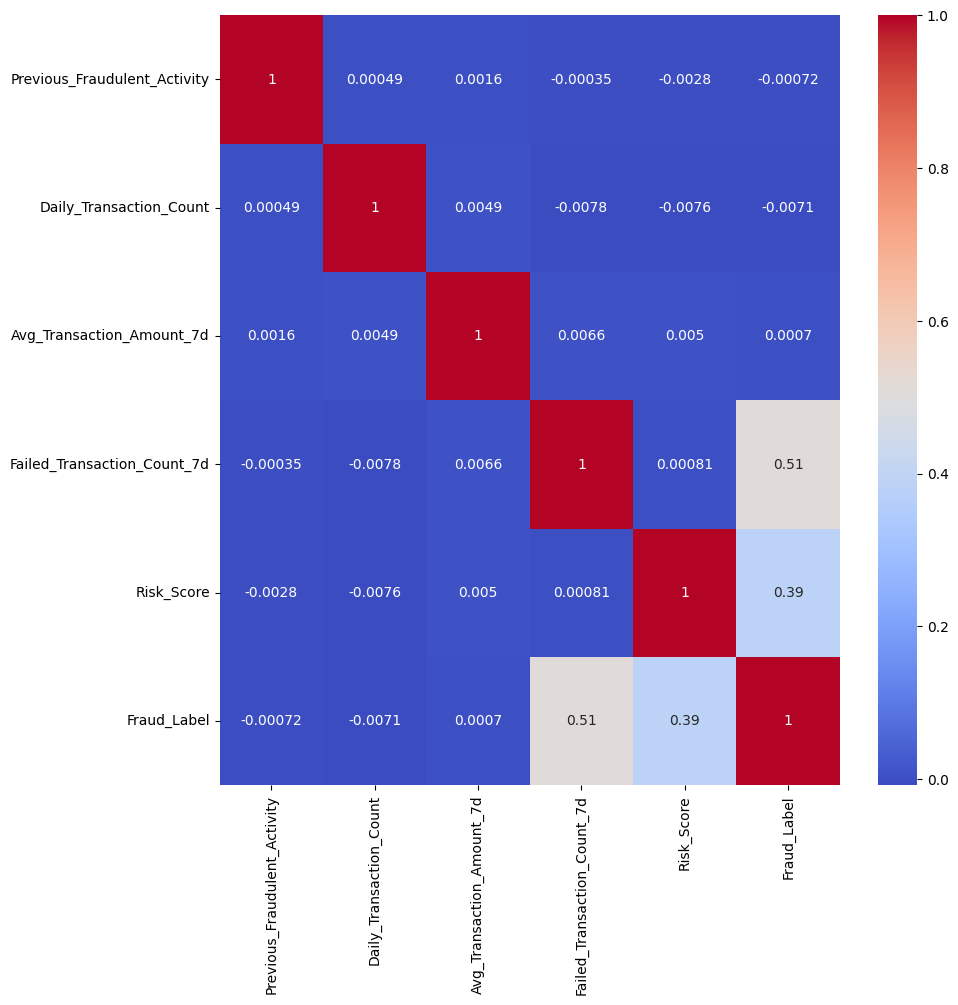

In [ ]:
# Visualização da matriz de correlação dos dados numéricos
plt.figure(figsize=(10, 10))
sns.heatmap(df[col_num].corr(), annot=True, cmap="coolwarm")
plt.show()

**Observação Importante** 
`
A matriz de correlação demonstra que as features: "Failed_Transaction_Count_7d" e "Risk_Score"
apresentam uma boa correlação com a feature alvo: "Fraud_Label"
`

In [ ]:
# Separando X e y do nosso dataframe
target = "Fraud_Label"

X = df.drop(columns=[target], axis=1)
y = df[target]

# Novamente separando as features numéricas das categóricas
col_cat = X.select_dtypes(include=["object", "category"]).columns
col_num = X.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
# A função train_test_split da biblioteca sklearn faz a separação dos valores de treino e teste para o modelo 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Separação das features que precisam ser normalizadas**
`
As variáveis "cols_norm" e "cols_no_norm" são listas dos nomes das features
que serão (ou não) necessárias normalizar.
`

In [ ]:
# A escolha foi feita com base do tamanho dos valores presentes
cols_norm = [
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d"
]

# Features binárias ou com valores muito pequenos
cols_no_norm = [
    "Previous_Fraudulent_Activity",
    "Risk_Score"
]

In [ ]:
# Tranformando as features categóricas em features numéricas
preprocess = ColumnTransformer(
    transformers=[
        ("num_norm", MinMaxScaler(), cols_norm),
        ("num_raw", "passthrough", cols_no_norm),
        ("cat", OneHotEncoder(handle_unknown="ignore"), col_cat)
    ]
)

**Observação:** `
O modelo não consegue entender dados categóricos, ou seja, "strings". Devido a isso,
fiz uso do OneHotEncoder para fazer esse trabalho de conversão de tipos
`

In [ ]:
# Essa pipeline é a chave de todo processo
# Ela contém o preprocessamento + O modelo de regressão logística prontos para uso
pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            random_state=42,
            max_iter=1000,
            penalty="l2",
            alpha=0.0001,
            learning_rate="constant",
            eta0=0.001
        ))
    ]
)


# Treinamento
`
A etapa de treinamento, faz com que o modelo seja alimentado com os dados
e, posteriormente, faça as previsões dos testes.
`

In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_norm', MinMaxScaler(),
                                                  ['Daily_Transaction_Count',
                                                   'Avg_Transaction_Amount_7d',
                                                   'Failed_Transaction_Count_7d']),
                                                 ('num_raw', 'passthrough',
                                                  ['Previous_Fraudulent_Activity',
                                                   'Risk_Score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Transaction_Type', 'Merchant_Category', 'Card_Type',
       'Authentication_Method'],
      dtype='object'))])),
                ('clf',
                 SGDClassifier(class_weight='balanced', eta0=0.001,
                               learning_rate='constant', loss='log_loss',
                               random_state=42))])

In [ ]:
# Y chapeu
y_pred = pipe.predict(X_test)

In [ ]:
# Conferindo a normalização usada - MinMaxScaler
pipe.named_steps["preprocess"].named_transformers_["num_norm"]

MinMaxScaler()

# Métricas

In [ ]:
# Printando as métricas

print(f"Acurácia: {accuracy_score(y_test, y_pred)}")
print(f"Precisão: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1: {f1_score(y_test, y_pred)}")

Acurácia: 0.7965
Precisão: 0.6466992665036675
Recall: 0.8176197836166924
F1: 0.7221843003412969


**Mudando a normalização e verificando os impactos**
`
A normalização dos dados, faz com que o gráfico da função de perda
fique mais simplificado para que o gradiente encontre um mínimo global.
Assim, fiz o teste com mais de uma normalização e verifiquei se há algum impacto nas métricas
`

In [ ]:
# Modificando o minMax para StandardScaler()
preprocess = ColumnTransformer(
    transformers=[
        ("num_norm", StandardScaler(), cols_norm),
        ("num_raw", "passthrough", cols_no_norm),
        ("cat", OneHotEncoder(handle_unknown="ignore"), col_cat)
    ]
)
# Mesmo exemplo anterior
pipe_2 = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            random_state=42,
            max_iter=1000,
            penalty="l2",
            alpha=0.0001,
            learning_rate="constant",
            eta0=0.001
        ))
    ]
)


In [ ]:
pipe_2.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_norm', StandardScaler(),
                                                  ['Daily_Transaction_Count',
                                                   'Avg_Transaction_Amount_7d',
                                                   'Failed_Transaction_Count_7d']),
                                                 ('num_raw', 'passthrough',
                                                  ['Previous_Fraudulent_Activity',
                                                   'Risk_Score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Transaction_Type', 'Merchant_Category', 'Card_Type',
       'Authentication_Method'],
      dtype='object'))])),
                ('clf',
                 SGDClassifier(class_weight='balanced', eta0=0.001,
                               learning_rate='constant', loss='log_loss',
                               random_state=42))])

In [ ]:
# Segunda previsão
y_pred_2 = pipe_2.predict(X_test)

In [ ]:
# Verificando se está sendo usado o StandardScaler()
pipe.named_steps["preprocess"].named_transformers_["num_norm"]

StandardScaler()

In [ ]:
# Printando as métricas
print(f"Acurácia: {accuracy_score(y_test, y_pred_2)}")
print(f"Precisão: {precision_score(y_test, y_pred_2)}")
print(f"Recall: {recall_score(y_test, y_pred_2)}")
print(f"F1: {f1_score(y_test, y_pred_2)}")

Acurácia: 0.7969
Precisão: 0.6483489403647117
Recall: 0.8132921174652241
F1: 0.7215137803373097


# **Análise dos resultados**

MinMax
`
Acurácia: 0.7965
Precisão: 0.6466992665036675
Recall: 0.8176197836166924
F1: 0.7221843003412969
`

StandarScaler
`
Acurácia: 0.7969
Precisão: 0.6483489403647117
Recall: 0.8132921174652241
F1: 0.7215137803373097
`


**Como pode-se observar, a mudança de normalizador trouxe muita pouca diferença. O que nos leva a acreditar, que o melhor para esse caso é usar um algorítmo de redes neurais para esse treinamento.**

In [2]:
y_pred = pipe.predict_proba(X_test)[:,1]
y_pred_2 = pipe_2.predict_proba(X_test)[:,1]

NameError: name 'pipe' is not defined

In [ ]:
# Visualizando a curva Roc
fpr, tpr, _ = roc_curve(y_test, y_pred_2)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

`A Curva ROC indica boa capacidade de separação entre transações fraudulentas e legítimas, com AUC de 0.89, evidenciando que o modelo apresenta desempenho significativamente superior ao acaso, mesmo utilizando uma abordagem linear.
`

**Autor**: *Arthur Pereira Tavares*